In [ ]:
pip install opencv-python numpy

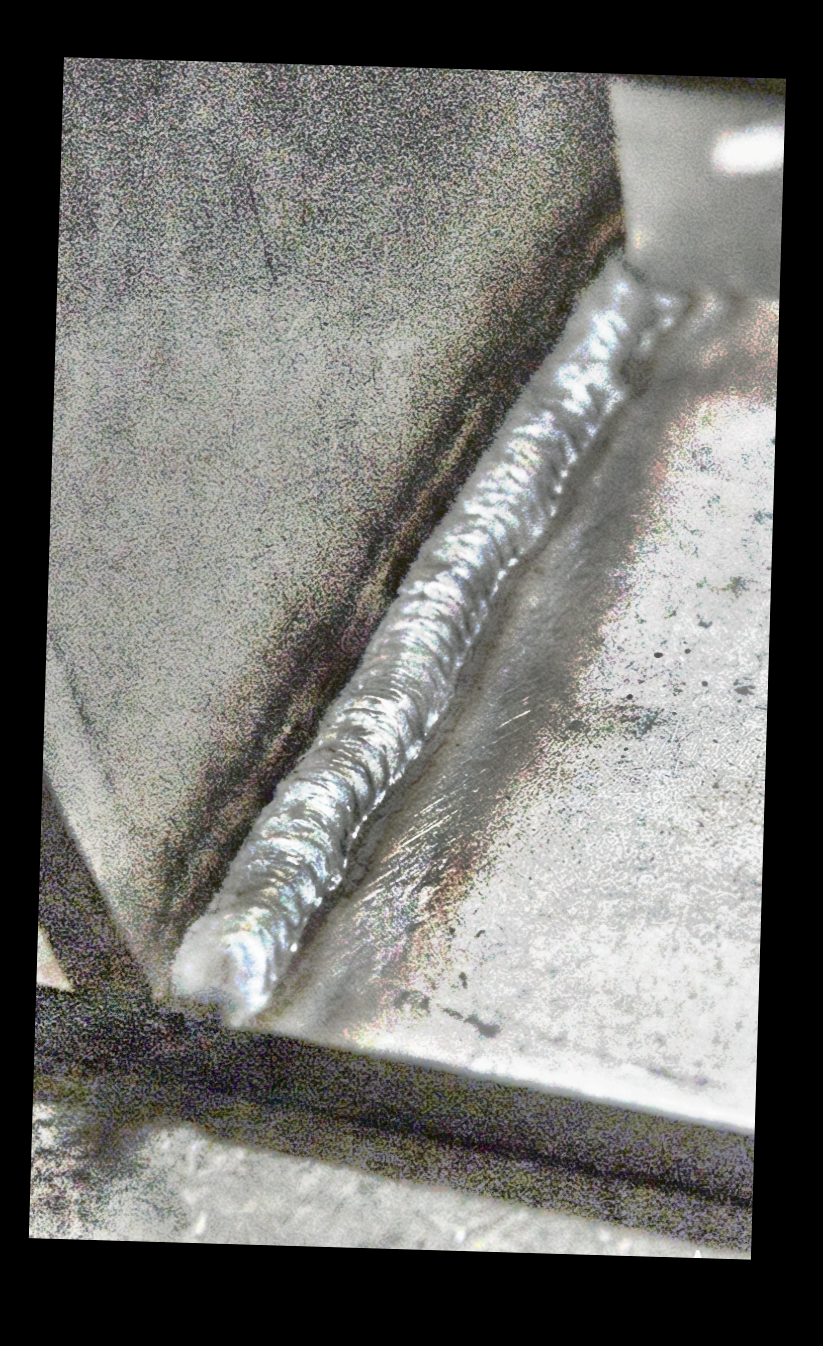

In [15]:
import cv2
import numpy as np
from skimage.exposure import match_histograms
from google.colab.patches import cv2_imshow # Import cv2_imshow

def robust_preprocess(target_path, ref_path):
    # Load images
    target = cv2.imread(target_path)
    ref = cv2.imread(ref_path)

    if target is None or ref is None:
        return "Error: Check file paths and extensions (.jpg vs .png)"

    # Ensure same size
    target = cv2.resize(target, (ref.shape[1], ref.shape[0]))

    # Stabilize Lighting (Histogram Matching)
    try:
        step1 = match_histograms(target, ref, channel_axis=-1)
    except:
        step1 = target # Fallback if matching fails

    # Sharpen Weld Details (CLAHE)
    lab = cv2.cvtColor(step1.astype(np.uint8), cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    step1_final = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

    # Robust Alignment (ORB with relaxed thresholds)
    # SIFT often fails on smooth metal; ORB is sometimes better for edges
    orb = cv2.ORB_create(5000)
    kp1, des1 = orb.detectAndCompute(step1_final, None)
    kp2, des2 = orb.detectAndCompute(ref, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    # Sort by distance
    matches = sorted(matches, key=lambda x: x.distance)

    if len(matches) > 15:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

        # Use Affine instead of Homography (more stable for 3D-to-2D views)
        M, inliers = cv2.estimateAffinePartial2D(src_pts, dst_pts)

        if M is not None:
            aligned = cv2.warpAffine(step1_final, M, (ref.shape[1], ref.shape[0]))
            return aligned

    print("Alignment failed - returning lighting-stabilized image only.")
    return step1_final



result = robust_preprocess('light3.png', 'angle3.png')
cv2.imwrite('stabilized_output.jpg', result)
cv2_imshow(result)